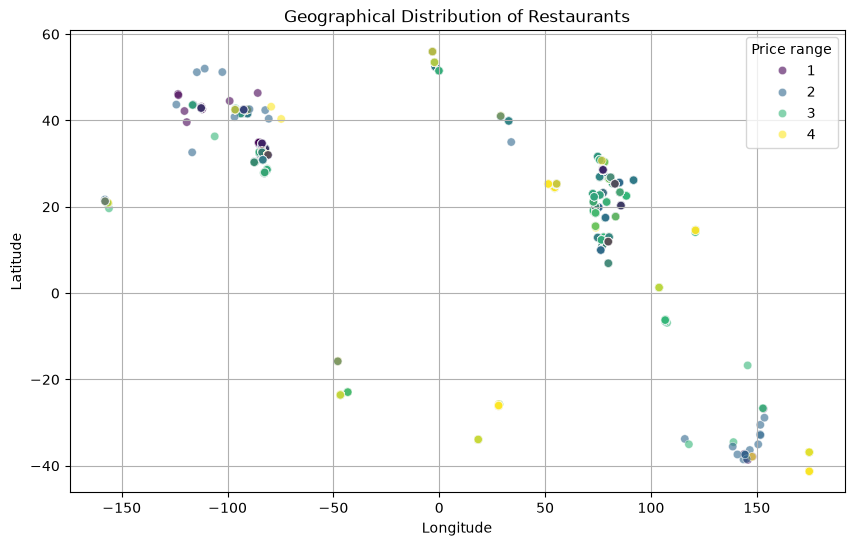

--- Top 10 Cities by Restaurant Count ---
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

--- Summary Statistics for Top 10 Cities ---


,Restaurant_Count,Average_Rating,Average_Price_Range,Average_Votes
City,,,,
New Delhi,5473,2.44,1.62,114.81
Gurgaon,1118,2.65,1.86,118.21
Noida,1080,2.04,1.60,68.04
Faridabad,251,1.87,1.45,25.84
Ghaziabad,25,2.85,1.80,94.64
Ahmedabad,21,4.16,2.57,584.10
Amritsar,21,3.69,1.81,174.52
Bhubaneshwar,21,3.98,1.86,202.05
Lucknow,21,4.20,2.57,434.76



--- Most Popular Cuisines in Top 5 Cities ---
New Delhi: North Indian
Gurgaon: North Indian
Noida: North Indian
Faridabad: North Indian
Ghaziabad: North Indian


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv("Dataset .csv")
df.columns = df.columns.str.strip()

# 2. Map Visualization using Scatter Plot (Latitude & Longitude)
plt.figure(figsize=(10, 6))
# Filter out invalid 0,0 coordinates for accurate spatial mapping
valid_coords = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]
sns.scatterplot(
    data=valid_coords, 
    x='Longitude', 
    y='Latitude', 
    hue='Price range', 
    palette='viridis', 
    alpha=0.6
)
plt.title('Geographical Distribution of Restaurants')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

# 3. Restaurant Concentration by City
print("--- Top 10 Cities by Restaurant Count ---")
city_counts = df['City'].value_counts().head(10)
print(city_counts)

# 4. Key Metrics Aggregated by City
print("\n--- Summary Statistics for Top 10 Cities ---")
top_cities = city_counts.index
city_stats = df[df['City'].isin(top_cities)].groupby('City').agg(
    Restaurant_Count=('Restaurant Name', 'count'),
    Average_Rating=('Aggregate rating', 'mean'),
    Average_Price_Range=('Price range', 'mean'),
    Average_Votes=('Votes', 'mean')
).round(2).sort_values(by='Restaurant_Count', ascending=False)

display(city_stats)

# 5. Top Cuisines by City
print("\n--- Most Popular Cuisines in Top 5 Cities ---")
for city in top_cities[:5]:
    top_cuisine = df[df['City'] == city]['Cuisines'].value_counts().idxmax()
    print(f"{city}: {top_cuisine}")